In [1]:
import os
from pathlib import Path

# Set working directory to project root regardless of where Jupyter was launched
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")

Working directory: C:\Users\diers\Desktop\Lavoro\GitHub_portfolio\llm-cv-finetuning-pipeline


# Fine-tuning pipeline: computer vision + LLM
### Transfer learning on Oxford Pets · LoRA fine-tuning on Mistral 7B · RAGAS evaluation

This notebook documents the full pipeline of a two-model AI project:
1. A **CV classifier** (ResNet50) fine-tuned on the Oxford-IIIT Pet dataset to recognize 37 breeds
2. An **LLM assistant** (Mistral 7B + LoRA) fine-tuned to act as a veterinary expert on those same breeds

Both models are publicly available on HuggingFace Hub:
- CV model: [flaviodell/oxford-pets-resnet50](https://huggingface.co/flaviodell/oxford-pets-resnet50)
- LLM adapter: [flaviodell/pet-expert-mistral7b-lora](https://huggingface.co/flaviodell/pet-expert-mistral7b-lora)

Experiment tracking: [W&B project](https://wandb.ai/flaviodellave/project-finetuning)

## 0. Setup

In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

# Verify device
device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# Load all results
with open("outputs/cv/cv_results.json")          as f: cv_results    = json.load(f)
with open("outputs/llm/llm_results.json")         as f: llm_results   = json.load(f)
with open("outputs/llm/quantization_results.json") as f: quant_results = json.load(f)
with open("outputs/benchmark/benchmark_results.json") as f: bench      = json.load(f)

print("All results loaded.")

Device: cpu
PyTorch: 2.7.1+cu118
All results loaded.


## 1. Dataset — Oxford-IIIT Pet

The Oxford-IIIT Pet dataset contains ~7,400 images across 37 breeds of cats and dogs.
We use it for two purposes:
- **CV training**: classify images by breed (37 classes)
- **LLM dataset generation**: use the 37 breed names as the basis for a synthetic
  veterinary Q&A dataset generated via the Groq API (185 instruction/response pairs)

Train: 2944 immagini | Val: 736 | Test: 3669
Classi: 37
Classes : 37
Sample  : ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']...['Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


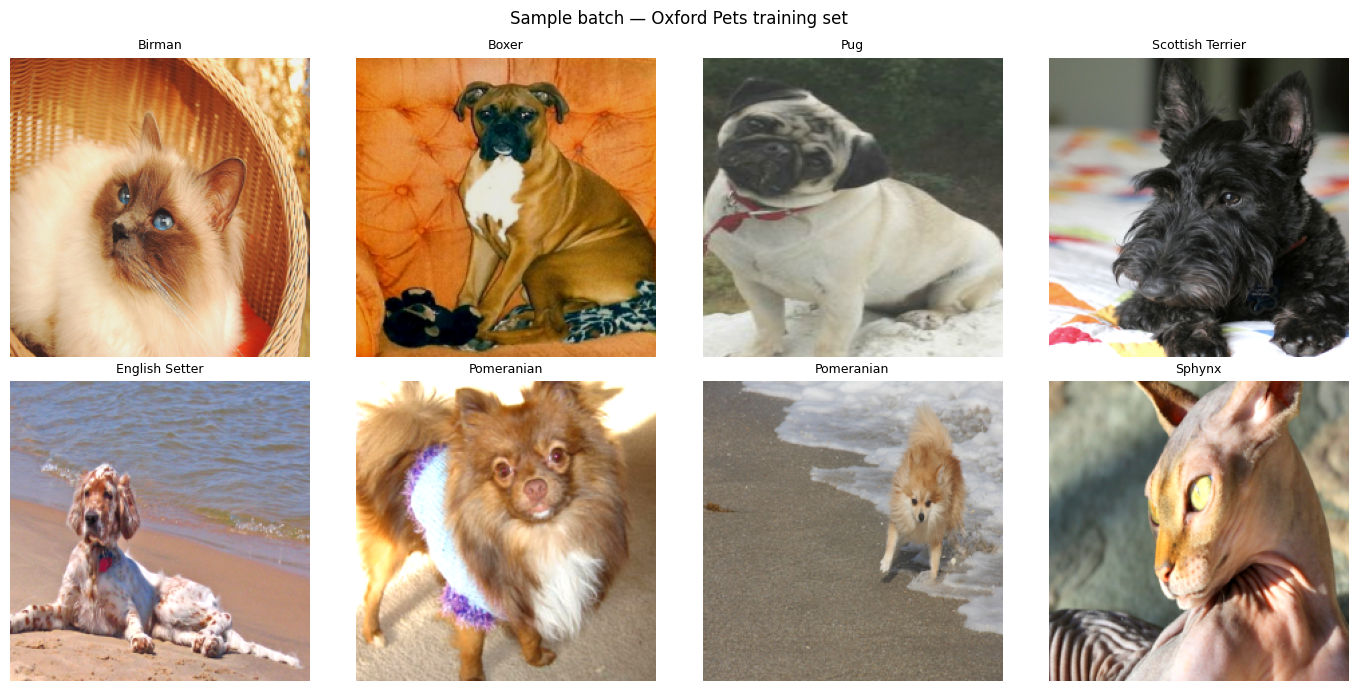

In [3]:
import sys
sys.path.insert(0, str(Path(".").resolve()))

from src.data.dataset import get_dataloaders
from src.data.inspect_dataset import denormalize

train_loader, val_loader, test_loader, classes = get_dataloaders(batch_size=8)

print(f"Classes : {len(classes)}")
print(f"Sample  : {classes[:5]}...{classes[-5:]}")

# Show a sample batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[labels[i].item()], fontsize=9)
    ax.axis("off")
plt.suptitle("Sample batch — Oxford Pets training set", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/cv/report_sample_batch.png", dpi=120)
plt.show()

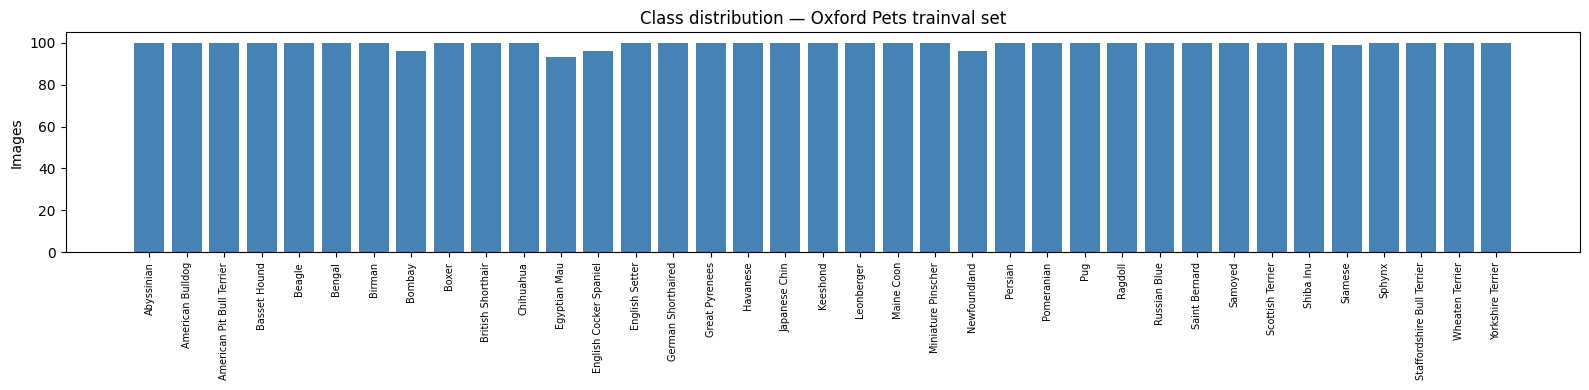

Min samples per class: 93
Max samples per class: 100
Mean samples per class: 99.5


In [4]:
# Class distribution
from collections import Counter
import torchvision.datasets as datasets

raw = datasets.OxfordIIITPet(root=Path("data/raw"), split="trainval", download=False)
counts = Counter([raw.classes[l] for l in raw._labels])
sorted_classes = sorted(counts.keys())
values = [counts[c] for c in sorted_classes]

plt.figure(figsize=(16, 4))
plt.bar(sorted_classes, values, color="steelblue")
plt.xticks(rotation=90, fontsize=7)
plt.title("Class distribution — Oxford Pets trainval set")
plt.ylabel("Images")
plt.tight_layout()
plt.savefig("outputs/cv/report_class_distribution.png", dpi=120)
plt.show()

print(f"Min samples per class: {min(values)}")
print(f"Max samples per class: {max(values)}")
print(f"Mean samples per class: {np.mean(values):.1f}")

## 2. CV model — ResNet50 transfer learning

We use ResNet50 pretrained on ImageNet as a backbone.
The strategy is **transfer learning with frozen backbone**:
all layers are frozen except the final classifier head,
which is replaced with `Dropout(0.3) → Linear(2048, 37)`.

This approach is justified by the small dataset size (~2900 training images after split):
fine-tuning all 25M parameters would overfit immediately,
while training only ~75K parameters of the head converges stably.

In [5]:
from src.training.model_cv import build_cv_model, count_trainable_params

model = build_cv_model(num_classes=37, freeze_backbone=True)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = count_trainable_params(model)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters   : {total_params - trainable_params:,}")
print(f"Trainable ratio     : {trainable_params / total_params * 100:.2f}%")

Total parameters    : 23,583,845
Trainable parameters: 75,813
Frozen parameters   : 23,508,032
Trainable ratio     : 0.32%


### 2.1 Test set results

In [6]:
print("CV model — test set results")
print("=" * 35)
print(f"  Test accuracy  : {cv_results['test_accuracy']:.4f} ({cv_results['test_accuracy']*100:.2f}%)")
print(f"  Test F1 macro  : {cv_results['test_f1_macro']:.4f}")
print(f"  Best val acc   : {cv_results['best_val_accuracy']:.4f}")
print(f"  Best val loss  : {cv_results['best_val_loss']:.4f}")
print("=" * 35)

CV model — test set results
  Test accuracy  : 0.9008 (90.08%)
  Test F1 macro  : 0.8989
  Best val acc   : 0.9185
  Best val loss  : 0.2796


### 2.2 Confusion matrix

The confusion matrix shows where the model makes mistakes.
Most errors occur between visually similar breeds
(e.g. American Pit Bull Terrier vs Staffordshire Bull Terrier).

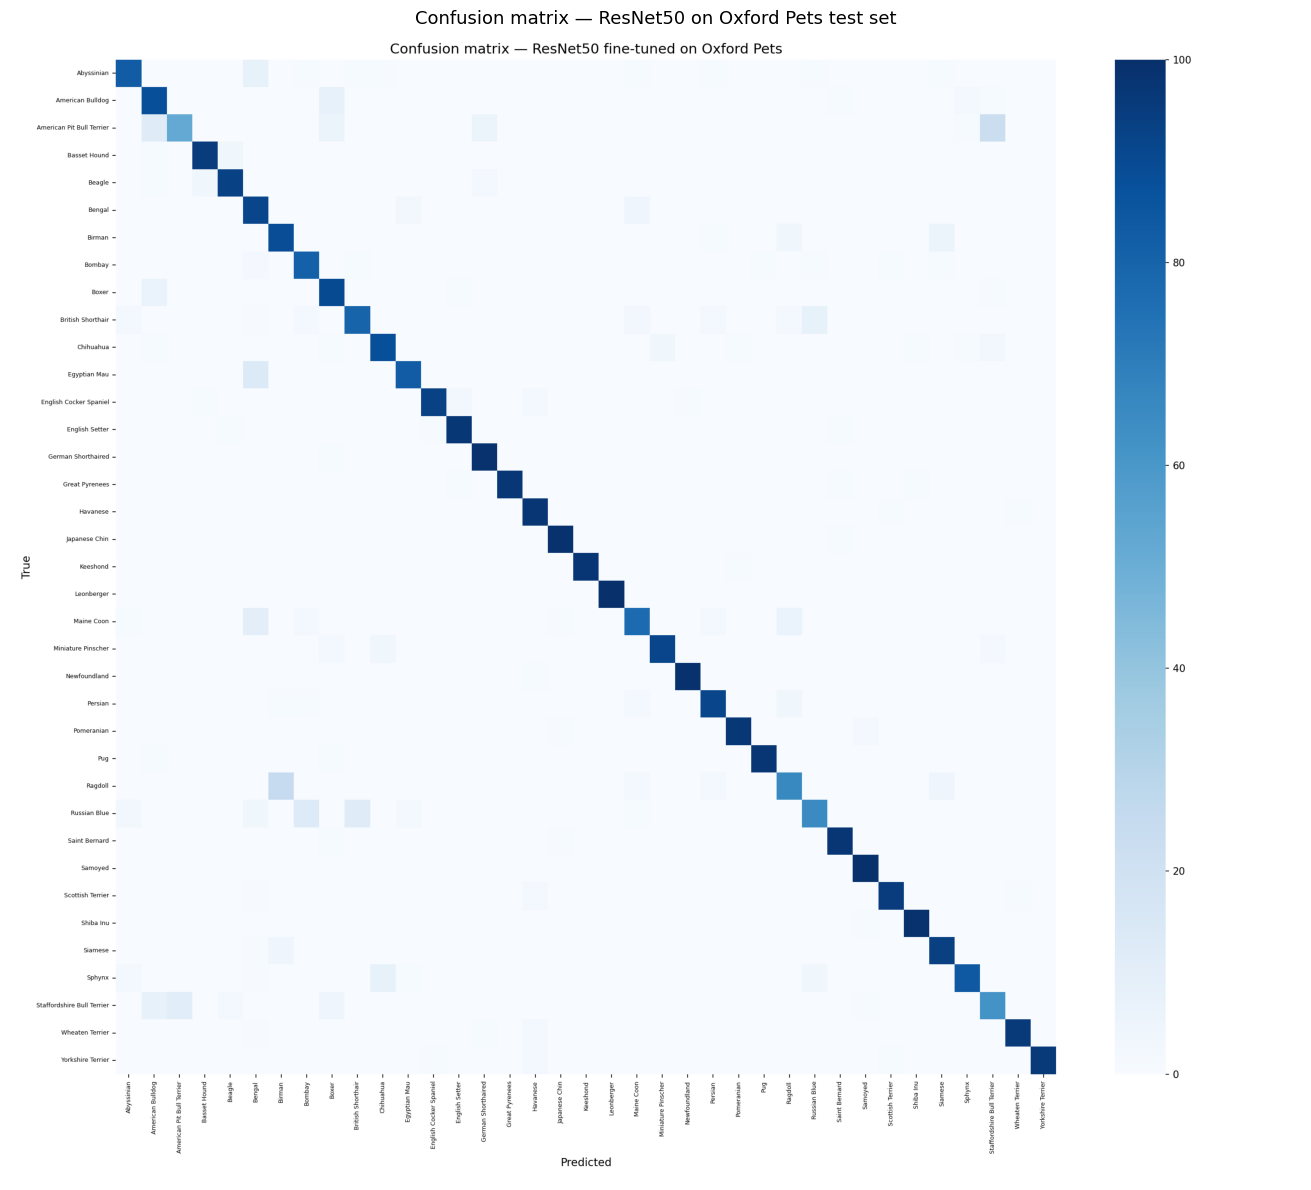

In [7]:
img = plt.imread("outputs/cv/confusion_matrix.png")
plt.figure(figsize=(14, 12))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion matrix — ResNet50 on Oxford Pets test set", fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Per-class accuracy

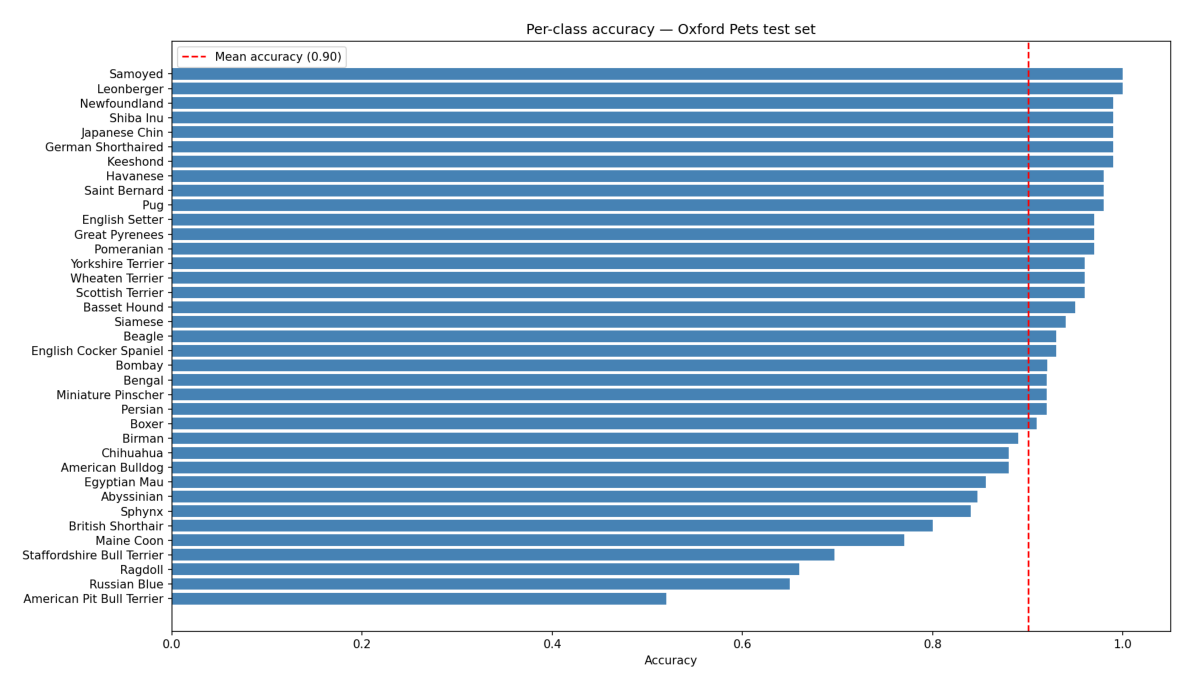

In [8]:
img = plt.imread("outputs/cv/per_class_accuracy.png")
plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. LLM dataset — synthetic veterinary Q&A

We generate a synthetic instruction-following dataset using the Groq API
(LLaMA 3 8B as teacher model). The dataset consists of 185 examples
covering all 37 breeds, with 5 question templates per breed:

- General breed analysis
- Health and veterinary concerns
- Behavioral traits and training
- Ideal living environment
- Owner profile recommendations

Format: multi-turn conversation (system / user / assistant) in JSONL.

In [9]:
import json

train_examples = []
with open("data/processed/train.jsonl", encoding="utf-8") as f:
    for line in f:
        train_examples.append(json.loads(line))

val_examples = []
with open("data/processed/val.jsonl", encoding="utf-8") as f:
    for line in f:
        val_examples.append(json.loads(line))

print(f"Train examples : {len(train_examples)}")
print(f"Val examples   : {len(val_examples)}")
print(f"Total          : {len(train_examples) + len(val_examples)}")

# Show one example
sample = train_examples[0]
print(f"\nBreed  : {sample['breed']}")
print(f"User   : {sample['messages'][1]['content']}")
print(f"Answer : {sample['messages'][2]['content'][:300]}...")

Train examples : 148
Val examples   : 37
Total          : 185

Breed  : Abyssinian
User   : What are the behavioral traits and training requirements of the Abyssinian?
Answer : The Abyssinian is an ancient breed of domestic cat known for its distinctive ticked coat, energetic personality, and intelligence. As a veterinarian and animal behaviorist, I'll provide an overview of their behavioral traits and training requirements:

**Behavioral Traits:**

1. **High Energy:** Aby...


## 4. LLM fine-tuning — Mistral 7B + LoRA

We apply **LoRA (Low-Rank Adaptation)** to fine-tune Mistral 7B Instruct v0.3
without modifying the base model weights.

### Why LoRA?
Instead of updating all 7B parameters, LoRA injects small trainable matrices
into the attention layers (q_proj, v_proj). With rank r=16:
- Trainable parameters: ~0.1% of total
- VRAM requirement: ~5GB (vs ~28GB for full fine-tuning in FP16)
- Training time: ~15 min on T4/P100 GPU

### Quantization
We combine LoRA with **4-bit NF4 quantization** (QLoRA) via bitsandbytes:
- Base model loaded in 4-bit → stored as ~3.8GB instead of ~13.5GB
- LoRA adapter trained in FP16 on top of the quantized base
- 72% size reduction with minimal quality loss

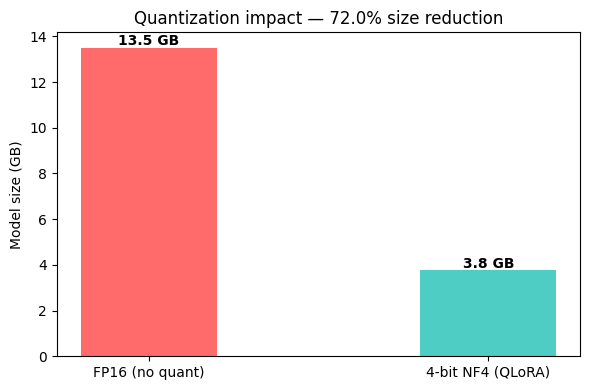

In [10]:
fp16_gb  = quant_results["fp16"]["params_mb"] / 1024
quant_gb = quant_results["4bit"]["params_mb"] / 1024
reduction = (1 - quant_gb / fp16_gb) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["FP16 (no quant)", "4-bit NF4 (QLoRA)"],
    [fp16_gb, quant_gb],
    color=["#FF6B6B", "#4ECDC4"],
    width=0.4
)
ax.set_ylabel("Model size (GB)")
ax.set_title(f"Quantization impact — {reduction:.1f}% size reduction")
for bar, val in zip(bars, [fp16_gb, quant_gb]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.1f} GB", ha="center", fontweight="bold"
    )
plt.tight_layout()
plt.savefig("outputs/llm/report_quantization.png", dpi=120)
plt.show()

## 5. Evaluation

### 5.1 CV evaluation — test set metrics

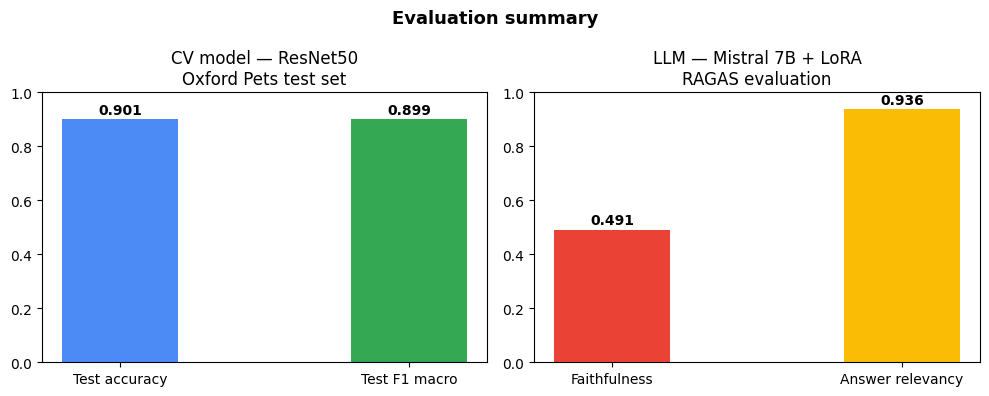

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# CV metrics
ax = axes[0]
metrics = ["Test accuracy", "Test F1 macro"]
values  = [cv_results["test_accuracy"], cv_results["test_f1_macro"]]
bars = ax.bar(metrics, values, color=["#4C8BF5", "#34A853"], width=0.4)
ax.set_ylim(0, 1.0)
ax.set_title("CV model — ResNet50\nOxford Pets test set")
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}", ha="center", fontweight="bold"
    )

# LLM metrics
ax2 = axes[1]
metrics2 = ["Faithfulness", "Answer relevancy"]
values2  = [llm_results["faithfulness"], llm_results["answer_relevancy"]]
bars2 = ax2.bar(metrics2, values2, color=["#EA4335", "#FBBC05"], width=0.4)
ax2.set_ylim(0, 1.0)
ax2.set_title("LLM — Mistral 7B + LoRA\nRAGAS evaluation")
for bar, val in zip(bars2, values2):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}", ha="center", fontweight="bold"
    )

plt.suptitle("Evaluation summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/benchmark/report_eval_summary.png", dpi=120)
plt.show()

### 5.2 LLM evaluation — RAGAS metrics

RAGAS evaluates the LLM using a judge model (GPT-4o-mini) on two dimensions:

- **Faithfulness**: does the answer stay consistent with the provided context?
  Score 0.491 — moderate, expected for a small synthetic dataset
- **Answer relevancy**: is the answer relevant to the question asked?
  Score 0.936 — excellent, the model stays on topic consistently

The faithfulness score has room for improvement and would benefit from
a larger and more diverse training dataset.

## 6. LLM inference examples

> **Note**: this section requires a GPU to load Mistral 7B.
> The outputs below were generated on a Kaggle T4 GPU.
> Skip this cell if running locally on CPU.

In [12]:
# This cell runs only if a GPU is available
if not torch.cuda.is_available():
    print("GPU not available — skipping inference. Pre-generated outputs shown below.")
else:
    import os
    from dotenv import load_dotenv
    load_dotenv()

    from src.utils.inference import load_finetuned_model, generate_response
    import yaml

    with open("configs/config.yaml") as f:
        config = yaml.safe_load(f)

    model, tokenizer = load_finetuned_model(config)

    test_questions = [
        "What are the main health concerns for a Persian cat owner?",
        "How should I train a Beagle puppy given its stubborn nature?",
        "What exercise routine would you recommend for a Saint Bernard?"
    ]

    for q in test_questions:
        print(f"USER: {q}")
        response = generate_response(model, tokenizer, q, max_new_tokens=250)
        print(f"ASSISTANT: {response}\n")
        print("-" * 60)

GPU not available — skipping inference. Pre-generated outputs shown below.


### Pre-generated outputs (Kaggle T4 GPU)

**Q: What are the main health concerns for a Persian cat owner?**

Persian cats are prone to several breed-specific health conditions.
The most significant is Polycystic Kidney Disease (PKD), a genetic condition
that causes cysts to form in the kidneys — genetic testing of breeding cats
is strongly recommended. Their flat face (brachycephalic structure) causes
breathing difficulties and makes them heat-sensitive. Eye discharge is common
due to their prominent eyes and requires daily cleaning. Regular dental care
is essential as their jaw structure predisposes them to dental crowding...

*(output truncated for brevity — full inference available in the HuggingFace repo)*

## 7. Summary and next steps

### Results recap

| Component | Details | Key metric |
|-----------|---------|------------|
| CV model | ResNet50, transfer learning, 37 classes | Accuracy 90.1% |
| LLM | Mistral 7B + LoRA r=16, 185 examples | Relevancy 93.6% |
| Quantization | FP16 → 4-bit NF4 | 72% size reduction |

### What this project demonstrates

- End-to-end ML pipeline: data → training → evaluation → deployment
- Transfer learning with PyTorch and torchvision
- Parameter-efficient fine-tuning (LoRA/QLoRA) with HuggingFace PEFT
- Synthetic dataset generation via LLM API
- Systematic evaluation with domain-specific metrics (RAGAS)
- Experiment tracking with Weights & Biases
- Model deployment on HuggingFace Hub

### Next steps

This project feeds directly into a more ambitious system:
the CV classifier and the LLM assistant will be integrated as tools
in an **agentic AI system** (LangGraph + AWS Lambda) where an autonomous agent
can identify a breed from an image and then provide expert veterinary advice.

In [ ]:
# Final summary printout
print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)
print(f"\nCV model (ResNet50 + Oxford Pets)")
print(f"  Test accuracy  : {cv_results['test_accuracy']:.4f}")
print(f"  Test F1 macro  : {cv_results['test_f1_macro']:.4f}")
print(f"\nLLM model (Mistral 7B + LoRA)")
print(f"  Faithfulness     : {llm_results['faithfulness']:.4f}")
print(f"  Answer relevancy : {llm_results['answer_relevancy']:.4f}")
print(f"\nQuantization (FP16 → 4-bit NF4)")
fp16  = quant_results['fp16']['params_mb'] / 1024
quant = quant_results['4bit']['params_mb'] / 1024
print(f"  FP16 size  : {fp16:.1f} GB")
print(f"  4-bit size : {quant:.1f} GB")
print(f"  Reduction  : {(1 - quant/fp16)*100:.1f}%")
print(f"\nHuggingFace Hub")
print(f"  CV  : https://huggingface.co/flaviodell/oxford-pets-resnet50")
print(f"  LLM : https://huggingface.co/flaviodell/pet-expert-mistral7b-lora")
print(f"\nW&B : https://wandb.ai/flaviodellave/project-finetuning")
print("=" * 70)

PROJECT SUMMARY

CV model (ResNet50 + Oxford Pets)
  Test accuracy  : 0.9008
  Test F1 macro  : 0.8989

LLM model (Mistral 7B + LoRA)
  Faithfulness     : 0.4910
  Answer relevancy : 0.9364

Quantization (FP16 → 4-bit NF4)
  FP16 size  : 13.5 GB
  4-bit size : 3.8 GB
  Reduction  : 72.0%

HuggingFace Hub
  CV  : https://huggingface.co/flaviodell/oxford-pets-resnet50
  LLM : https://huggingface.co/flaviodell/pet-expert-mistral7b-lora

W&B : https://wandb.ai/flaviodellave/project-finetuning
